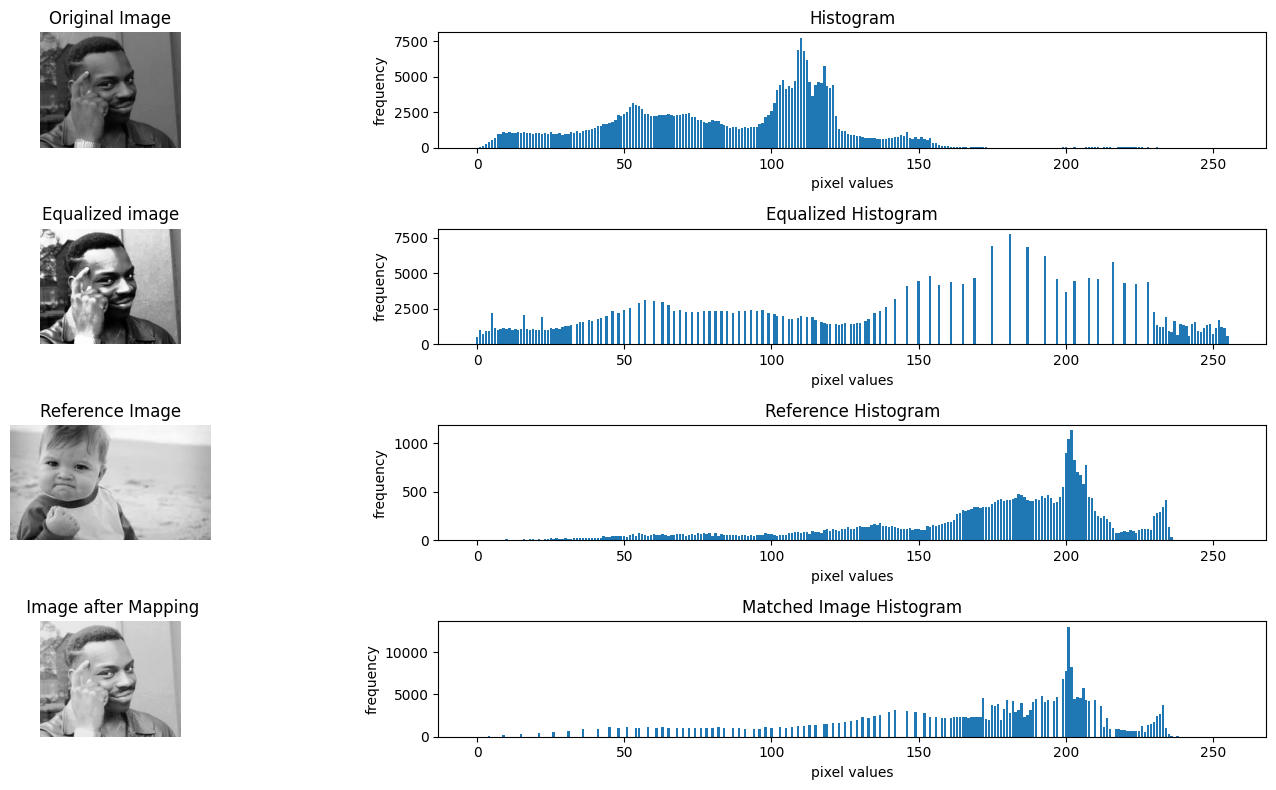

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

src_img = cv2.imread("images/think.jpg",cv2.IMREAD_GRAYSCALE)

if src_img is None:
    raise FileNotFoundError("Unable to load src image")

# Generating Histogram
img_hist = cv2.calcHist([src_img],[0],None,[256],[0,256])

# Histogram Equalization
eqz_img = cv2.equalizeHist(src_img)
eqz_hist = cv2.calcHist(
    [eqz_img],
    [0],
    None,
    [256],
    [0, 256]
)

# Histogram matching

# adding reference image
ref_img = cv2.imread(
    "images/yes!.jpg",
    cv2.IMREAD_GRAYSCALE
)

if ref_img is None:
    raise FileNotFoundError("Unable to load reference image")

# calculating histogram
ref_hist = cv2.calcHist([ref_img],[0],None,[256],[0,256])


# normalizing both histogram
src_hist_norm = img_hist / img_hist.sum()
ref_hist_norm = ref_hist / ref_hist.sum()

# finding cumulative sum
src_cdf = src_hist_norm.cumsum()
ref_cdf = ref_hist_norm.cumsum()

# Find the equivalent values of src_cdf in ref_cdf and store their intensity values in mapping
mapping = np.interp(src_cdf, ref_cdf, range(256))

# Replace source image pixel intensities according to the mapping
matched_img = mapping[src_img].astype(np.uint8)

matched_hist = cv2.calcHist([matched_img],[0],None,[256],[0,256])

x = list(range(256))

plt.figure(figsize=(16,8))

plt.subplot(4,2,1)
plt.title("Original Image")
plt.axis("off")
plt.imshow(src_img,cmap="gray")

plt.subplot(4,2,2)
plt.title("Histogram")
plt.xlabel("pixel values")
plt.ylabel("frequency")
plt.bar(x,img_hist)

plt.subplot(4,2,3)
plt.title("Equalized image")
plt.axis("off")
plt.imshow(eqz_img,cmap="gray")

plt.subplot(4,2,4)
plt.title("Equalized Histogram")
plt.xlabel("pixel values")
plt.ylabel("frequency")
plt.bar(x,eqz_hist)

plt.subplot(4,2,5)
plt.title("Reference Image")
plt.axis("off")
plt.imshow(ref_img,cmap="gray")

plt.subplot(4,2,6)
plt.title("Reference Histogram")
plt.xlabel("pixel values")
plt.ylabel("frequency")
plt.bar(x,ref_hist)

plt.subplot(4,2,7)
plt.title(" Image after Mapping")
plt.axis("off")
plt.imshow(matched_img,cmap="gray")

plt.subplot(4,2,8)
plt.title("Matched Image Histogram")
plt.xlabel("pixel values")
plt.ylabel("frequency")
plt.bar(x,matched_hist)

plt.tight_layout()

plt.show()